In [16]:
from IPython.display import Image

## 0. 영상을 이해하는 접근 방식   

### Top-down 방식
- 계층적으로 이미지안의 물체들을 구분하고 각 물체가 무엇이고 어떤 상태인지를 파학.
- 특징의 종류 
    - 물체의 영역 
    - 물체의 경계
    - 물체의 경계와 영역은 상호 보완적 

### bottom-up 방식
- 특징점을 사용하여 물체를 인식하고 이를 이용하여 전체를 이해하는 방법 
   
### 발전의 역사  
- 역사적으로 Top-down 방식의 2000년이전에 주로 연구의 방향이 었으나, 진보가 느렸고, 2000년이후에는 SIFT와 같은 특징점이 개발되면서  Bottom-up 방식이 주를 이루었다가, 2012년 Alexnet 이후로는 Deep-learning 방식이 대세를 이루고 있음.
-  그러나, 고전적인 접급 법에 대한 이해는 딥러닝등 방식을 이해하고 발전시키는데 큰 도움이 됨.

## 1. 에지 검출 

### 0) 에지 개념   
 
- 화소의 값이 크게 변화는 곳(화소)은 두개의 다른 물체의 경계일 가능성이 높음.
   - 같은 물체는 유사한 화소값을 가지고 있음 (자연 영상 (애니매이션 같은 인위적인 경우 제외)에서 통계적으로 Covariance가 0.8 이상)


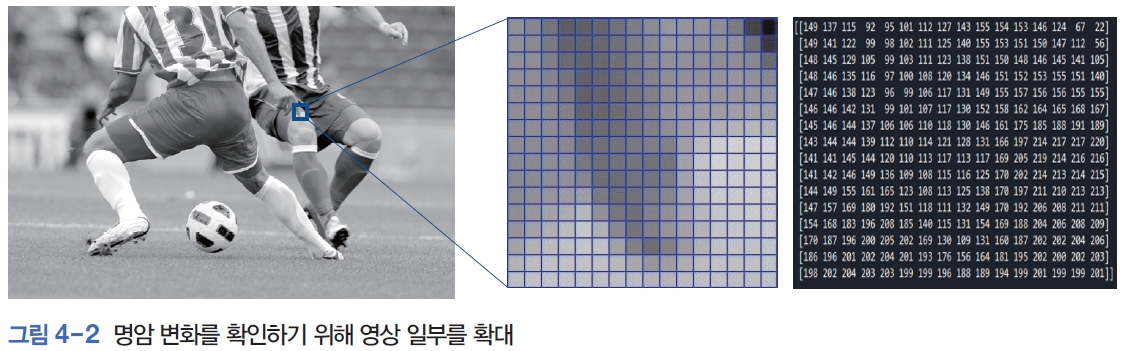

In [17]:
Image("그림 4-2.jpg", width=720)

### 1) 방법 

- 미분값 (차)과 일정 기준을 사용 

   - $ I'(t) =  (I(t + dt)  - I(t))/dt > T $



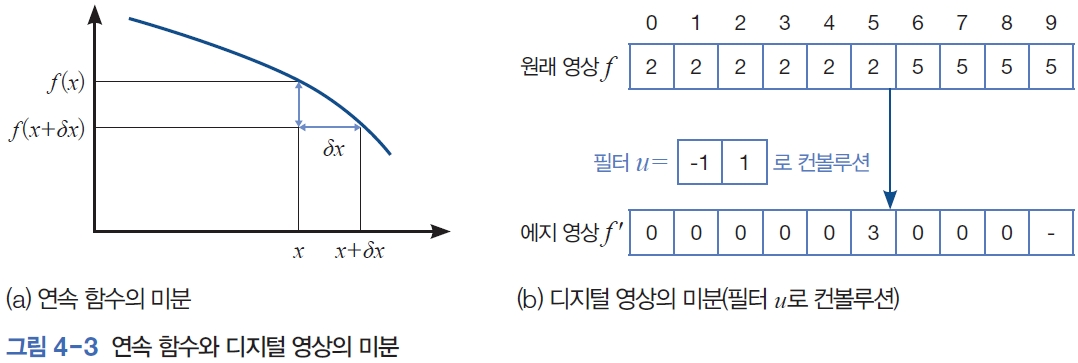

In [18]:
Image("그림 4-3.jpg", width=720)

####  디지털 영상의 에지
    
- 2차원으로 확장 (Gradient): 에지 벡터 $ (I'_x, I'_y) (y,x) $ 
     
    - $ I'_x(y,x) = (I(y, x + dx)  - I(y,x))/ dx$
    - $ I'_y(y,x)= (I(y + dy, x)  - I(y,x))/ dy$
    
- 벡터이므로 크기와, 방향으로 구분   
      
    - 그레디언드(에지) 강도:  $ s(y,x) = \sqrt(I'^2_x +  I'^2_y (y,x))$  
    - 그레디언드 방향:  $ d(y,x) = arctan( I'_y(y,x)/I'_x(y,x))$
         - **주의** 에지 방향은 그레디언방향과 수직 함, 또한 역방향도 수직함. 
         - **주의**: arctan( ) 와 arctan2(  , ) 의 차이를 아시나요?   
         - 방향은 이후에 처리를 위해서 N (16) 개 방향으로 그루핑하는 경우가 많음.  (예, HOG, SIFT 등)

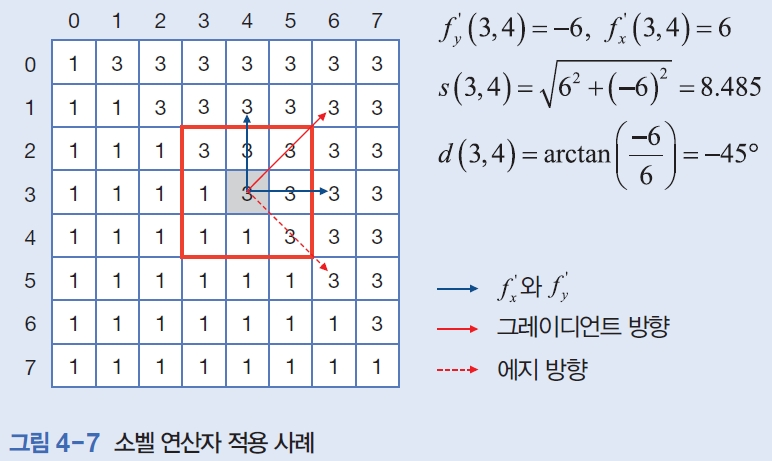

In [19]:
Image("그림 4-7.jpg", width=480)

### 2차원 이미지 에지필터 

- 초기에 여러가지 필터가 제안되었음.
- Sobel 필터 
    - 노이즈 제거를 위한 스무딩과 미분을 적용 
    - y 방향필터 (x 축으로 변화는 것을 감지) : $ [1, 2, 1] ^ T * [1,  0,  -1] $  
    - y 방향필터 (y 축으로 변화는 것을 감지) : $ [1,  0,  -1] * [1, 2, 1] ^ T $   

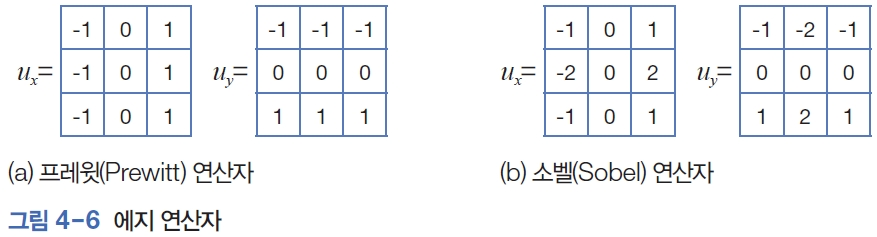

In [20]:
Image("그림 4-6.jpg", width=720)

### 3) OpenCV 기본 Edge 검출 방법 

- Sobel 에지 검출 
   - Kernel 크기 출력 데이터 타입등에 주의   
 

gx: float32 (600, 868)


(<Axes: title={'center': 'dxy'}>,
 Text(0.5, 1.0, 'dxy'),
 (-0.5, 867.5, 599.5, -0.5))

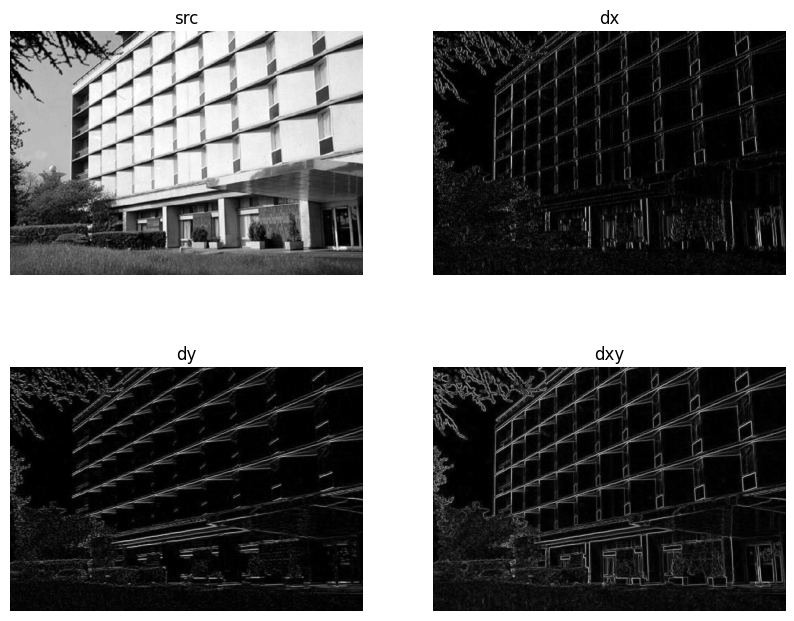

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

src = cv2.imread('building.jpg', cv2.IMREAD_GRAYSCALE)

#1 gradient dx, dy
gx = cv2.Sobel(src, cv2.CV_32F, 1, 0, ksize = 3)  # x order = 1 only 
gy = cv2.Sobel(src, cv2.CV_32F, 0, 1, ksize = 3)  # y 
print("gx:", gx.dtype, gx.shape)

# g 값은 양수와 음수가 있으므로, 절대치를 취하고, 크기도  [0, 255] 로 정규화    
dstX = np.abs(gx)
dstY = np.abs(gy)
dstXY =  dstX + dstY
dst_max = np.max(dstXY)
#print("max:", dst_max)
dstX = (dstX/dst_max*255).astype(np.uint8)
dstY = (dstY/dst_max*255).astype(np.uint8)
dstXY =(dstXY/dst_max*255).astype(np.uint8)

plt.figure(figsize=(10, 8))
plt.subplot(2,2,1), plt.imshow(src, cmap ='gray'), plt.title('src'), plt.axis('off')
plt.subplot(2,2,2), plt.imshow(dstX, cmap ='gray'), plt.title('dx'), plt.axis('off')   
plt.subplot(2,2,3), plt.imshow(dstY, cmap ='gray'), plt.title('dy'), plt.axis('off')
plt.subplot(2,2,4), plt.imshow(dstXY, cmap ='gray'), plt.title('dxy'), plt.axis('off')


###  에지 방향 계산 코드 (설명은 시간상 생략 할 것임)

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

src = cv2.imread('./building.jpg', cv2.IMREAD_GRAYSCALE)

#1 gradient dx, dy
gx = cv2.Sobel(src, cv2.CV_32F, 1, 0, ksize = 3)  # x order = 1 only 
gy = cv2.Sobel(src, cv2.CV_32F, 0, 1, ksize = 3)  # y 
print("gx:", gx.dtype, gx.shape)

#2. magnitude
# you can use this, but be carefull angle range is 0 to 360 degree
# mag, angle = cv2.cartToPolar(gx, gy, angleInDegrees=True)
dstM   = cv2.magnitude(gx, gy)
minVal, maxVal, minLoc, maxLoc = cv2.minMaxLoc(dstM)
print('mag:', minVal, maxVal, minLoc, maxLoc)

# 3. angle 
angles = np.arctan2(gy, gx)  # arctan (gy/gx)를 사용하지 않는 것은. 0 값으로 나누는 문제를 해결하기 위함
angles_standard = (angles + np.pi/2) % np.pi - np.pi/2
angles = angles/np.pi*180.0

# 양자화 (종더 효과적으로 양자화를 할수도 있죠? 해보세요)
dstAngles  = np.zeros([angles.shape[0], angles.shape[1]], dtype = np.uint8)
dstAngles[ angles < -67.5 ] = 1
dstAngles[ (angles >= -67.5) & (angles < -22.5) ] = 2
dstAngles[ (angles >= -22.5) & (angles < 22.5)  ] = 3
dstAngles[ (angles >= 22.5)  & (angles < 67.5)  ] = 4
dstAngles[ angles >= 67.5 ] = 5
dstAngles[dstM < 30] = 0  # masking non edge
print(np.count_nonzero(dstAngles[dstAngles == 1]))
print(np.count_nonzero(dstAngles[dstAngles == 2]))
print(np.count_nonzero(dstAngles[dstAngles == 3]))
print(np.count_nonzero(dstAngles[dstAngles == 4]))
print(np.count_nonzero(dstAngles[dstAngles == 5]))

gx: float32 (600, 868)
mag: 0.0 771.2651977539062 (0, 0) (485, 183)
92015
20538
43282
27644
87580


### 2) 2 차미분 & 영교차 방법 

- 실제 이미지 특성/현실 
    - 두화소사이 명확히  달라지지 않고 부드럽게 변화됨 (특히 ramp edge)
    - 카메라 특성 및 영상 블러링등에 의한 영향 
- 2차 미분 후 0교차
    - 1차 미분과 임계치를 사용하는 것 보다 성능이 좋고 임계치 설정이 불필요함

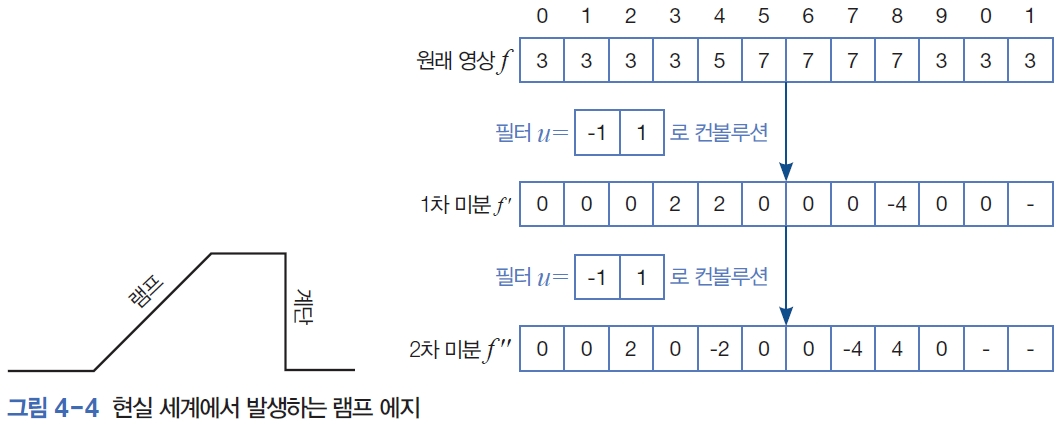

In [23]:
Image("그림 4-4.jpg", width=720)

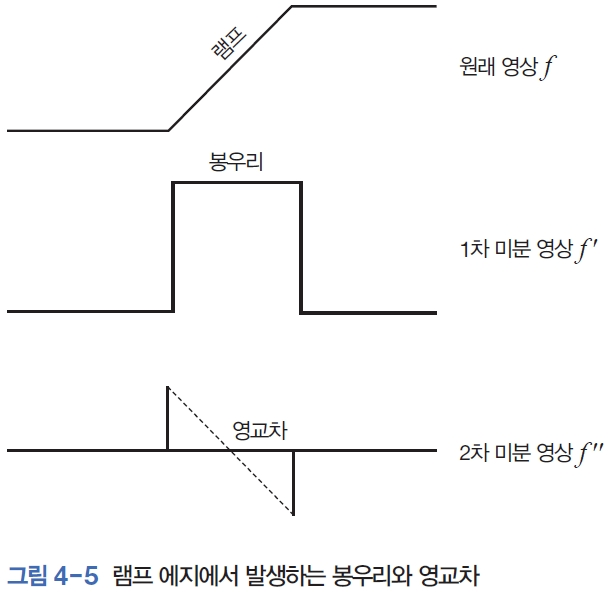

In [24]:
Image("그림 4-5.jpg", width=480)

## 2. Canny edge 

- 응용에 필요한 에지의 특성 

   - 에지의 두께가 1 화소 (가늘어야 함.)
   - 가능한 에지들간에 연결되어 있어야함.
   
- Canny edge 
  
   - Non-maximal supression (비 최대 억제)
   
       - 에지점의 방향좌우 방향으로 에지점들과 비교하여 주위의 값보다 값이 큰 경우만 남김 (값이 최고가 아닌 것을 제거함)
       
   - Hysteris Threshold
   
        - 임계치를 크고 $T_h$ 작은 $T_l$ 두개로 하고, 
        - 에지 강도 $ s(y,x) > T_h $ 인 점은 강한 에지점으로 선언 
        - 에지 강도 $ s(y,x) < T_l $ 인 점은 에지점에서 제외
        - $ T_l < s(y,x) < T_h $ 인 점들은 강한 에지점에서 연결이 가능하면 에지점으로 남김 
        
        
        
        
        
   
   

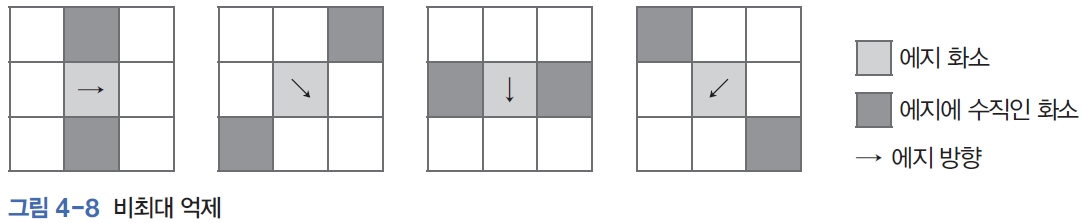

In [25]:
Image("그림 4-8.jpg", width=720)

### 3) OpenCV Canny Edge

- 에지가 sobel에 비하여 가늘어 졌는지 확인
- Hystery threshold 를 사용하지 않은 경우 ($T_H =  T_L$)와 사용하는 경우의 차이 확인

mag: 0.0 771.2651977539062 (0, 0) (485, 183)
mag: 0.0 255.0 (0, 0) (28, 0)
im_bin: float32 (600, 868)
canny edge: uint8 (600, 868)
min,   max: (0.0, 255.0, (0, 0), (28, 0))


(<Axes: title={'center': 'canny'}>,
 Text(0.5, 1.0, 'canny'))

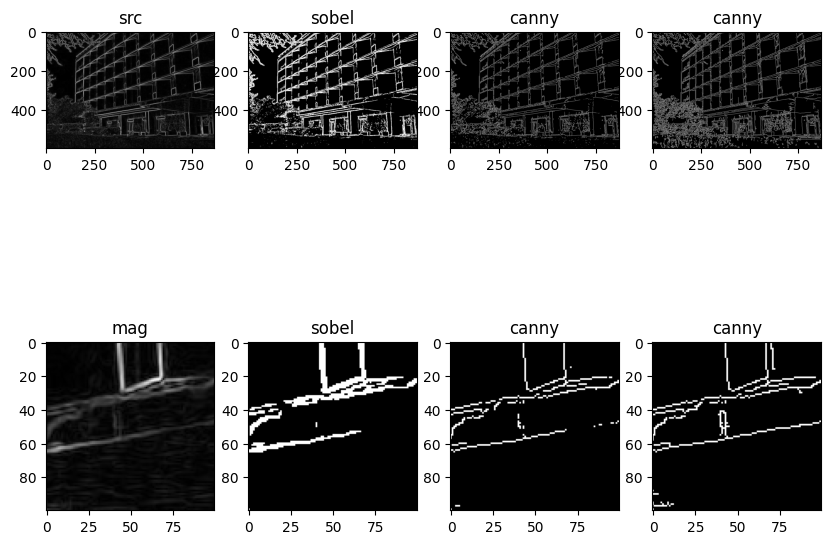

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
    
#im_path = "Lena.png"
im_path = "building.jpg"
im_src  = cv2.imread(im_path, cv2.IMREAD_GRAYSCALE)

def sobel_edge(im_gray, T):

    #1 dx, dy
    gx = cv2.Sobel(im_gray, cv2.CV_32F, 1, 0, ksize = 3)  # x order = 1 only 
    gy = cv2.Sobel(im_gray, cv2.CV_32F, 0, 1, ksize = 3)  # y 
    #print("gx:", gx.dtype, gx.shape)
    
    dstM   = cv2.magnitude(gx, gy) # need  CV_32F or CV_64F
    minVal, maxVal, minLoc, maxLoc = cv2.minMaxLoc(dstM)
    print('mag:', minVal, maxVal, minLoc, maxLoc)
    #dstM = cv2.normalize(dstM, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    
    _, im_bin = cv2.threshold(dstM, T, 255, cv2.THRESH_BINARY)
    minVal, maxVal, minLoc, maxLoc = cv2.minMaxLoc(im_bin)
    print('mag:', minVal, maxVal, minLoc, maxLoc)
    print("im_bin:", im_bin.dtype, im_bin.shape)
    return dstM, im_bin.astype(np.uint8)

# sobel edge for comparsion    
im_mag, im_sobel = sobel_edge(im_src, T = 127)
    
# sobel edge for comparison 
im_canny1 = cv2.Canny(im_src, threshold1= 127, threshold2 = 127)
im_canny2 = cv2.Canny(im_src, threshold1= 127, threshold2 = 61)

print("canny edge:", im_canny1.dtype, im_canny1.shape )
print("min,   max:", cv2.minMaxLoc(im_canny1))  # 0/255 (uint8)

plt.figure(figsize=(10, 8))
plt.subplot(2,4,1), plt.imshow(im_mag, cmap="gray"), plt.title('src')
plt.subplot(2,4,2), plt.imshow(im_sobel, cmap="gray"), plt.title('sobel')
plt.subplot(2,4,3), plt.imshow(im_canny1, cmap="gray"), plt.title('canny')
plt.subplot(2,4,4), plt.imshow(im_canny2, cmap="gray"), plt.title('canny')
plt.subplot(2,4,5), plt.imshow(im_mag[300:400, 600:700], cmap="gray"), plt.title('mag')
plt.subplot(2,4,6), plt.imshow(im_sobel[300:400, 600:700], cmap="gray"), plt.title('sobel')
plt.subplot(2,4,7), plt.imshow(im_canny1[300:400, 600:700], cmap="gray"), plt.title('canny')
plt.subplot(2,4,8), plt.imshow(im_canny2[300:400, 600:700], cmap="gray"), plt.title('canny')


## 3. 허프 변환 

- canny 에지방식이 상당히 연결성이 좋은 에지라인을 만들긴 하지만 물체를 둘러싸는 폐곡선을 만들어 내지는 못함.

- 실제 영역을 기하학적으로  구분하기 위해서는 간순한 도형, 선, 원 등으로 단순화하는 방법이 필요 

   - Hough Line :  선을 추출  (기울기, 절편)  
   - Hough Circle : 원을 추출 (원의 중심 좌표 x, y, 반경)
   - 선과 원의 파라메터를 추정하는 방식으로 접근함 

#### 허프 라인 변환 

- x, y 대신 기울기($\theta$),원점에서의 거리변수추정
    - $ x cos(\theta)  + y sin(\theta) = \rho $  
    - 우리가 잘아는 기울기와 절편을 사용하지 않은 이유는?  (범위가 무한대까지 됨)  
- 알고리즘 원리 
     - $(\theta, \rho)$ 공간을 양자화하여 2차원 배열로 만들고 ($ -\pi /2 < \theta < \pi/2,  - D < \rho < D $)
     - 에지점 하나하나가 $(\theta, \rho)$ 공간에서 지나는 모든 영역의 counter를 증가 시킴.
          - 한번 이거 코딩 해보세요! 
     - Non-Max-Supression을 사용하여 peak되는 곳의 크기가 일정 값이상이면 line으로 선언  

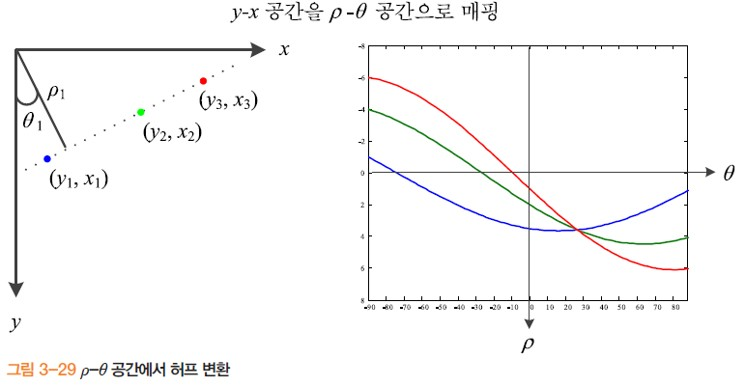

In [27]:
Image("houghline_theory.jpg", width=640)

## OpenCV Hough 변환

-  Hough Line 용으로 두가지 함수가 있음
    - HoughLines : 표준적인 Hougline 함수 
    - HoughLinesP:  line 이 아니라 line segment를 찾아줌
    
- HoughCircle 기능도 있음     

Hough Result:
0 -224.0 145.99999267917153
negative rho, theta > 90 
1 203.0 37.999999919081475
postive rho, theta < 90
2 -217.0 144.00000400716507
negative rho, theta > 90 
3 200.0 39.99999883637168
postive rho, theta < 90
4 198.0 39.00000108527387
postive rho, theta < 90
5 265.0 3.0000000834826057
postive rho, theta < 90
6 261.0 3.999999969014533
postive rho, theta < 90
7 133.0 56.99999817107492
postive rho, theta < 90
8 -160.0 125.00000234007703
negative rho, theta > 90 
9 137.0 56.99999817107492
postive rho, theta < 90
10 -153.0 123.99999434369548
negative rho, theta > 90 
11 -158.0 123.99999434369548
negative rho, theta > 90 
12 204.0 39.00000108527387
postive rho, theta < 90
13 -208.0 142.9999960107835
negative rho, theta > 90 
14 14.0 90.00000250447816
postive rho, theta > 90
15 7.0 90.00000250447816
postive rho, theta > 90
16 -228.0 145.99999267917153
negative rho, theta > 90 
17 -164.0 125.00000234007703
negative rho, theta > 90 
18 139.0 56.000000419977106
postive rho, theta <

(<Axes: title={'center': 'HoughLinesP'}>,
 (-0.5, 508.5, 337.5, -0.5),
 Text(0.5, 1.0, 'HoughLinesP'))

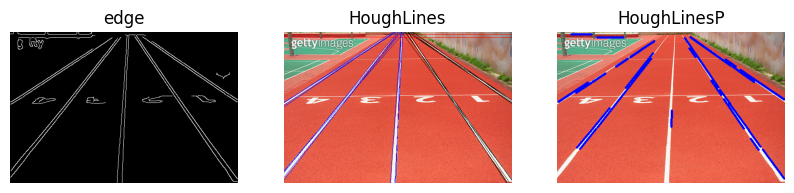

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# 1. load image  
im_bgr = cv2.imread('lane1.jpg')
im_gray = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2GRAY)

# 2. Canny edge 
im_gray = cv2.GaussianBlur(im_gray, ksize = (13,13), sigmaX= 2.0)
Tlow = 50
Thigh = 150
im_edge = cv2.Canny(im_gray, Tlow, Thigh, apertureSize = 3)

# 3. Hough Transform using 
T = 100
im_hough1 = im_bgr.copy()
lines = cv2.HoughLines(im_edge, 1, np.pi/180, T) 
print('Hough Result:')
for i, line in enumerate(lines):
    
    rho,theta = line[0]     # rho and theta
    print(i, rho, theta*180./np.pi)
    #  note: 수업에서는  y cos(theta) + x sin(theta) = rho
    #        그런데, slide_theta = opencv_theta - 90 이므로
    #        x cos (opencv_theta)  + y cos (opencv_theta) = rho 가 됨.    
   
    a = np.cos(theta)         
    b = np.sin(theta)
    x0 = a*rho              # 수직교점 
    y0 = b*rho
    t = 1000
    x1 = int(x0 + t*(-b))    
    y1 = int(y0 + t*(a))
    x2 = int(x0 - t*(-b))
    y2 = int(y0 - t*(a))
    if  rho > 0 and theta < np.pi/2.:
        print('postive rho, theta < 90')
        cv2.line(im_hough1,(x1,y1),(x2,y2),(255,0,0),1) # blue
    elif rho > 0 and theta > np.pi/2.:
        print('postive rho, theta > 90')
        cv2.line(im_hough1,(x1,y1),(x2,y2),(0,0,255),1) # red
    elif rho < 0 and theta < np.pi/2.:
        print('negative rho, theta < 90')
        cv2.line(im_hough1,(x1,y1),(x2,y2),(0,255,0),1) # green
    elif rho < 0 and theta > np.pi/2.:
        print('negative rho, theta > 90 ')
        cv2.line(im_hough1,(x1,y1),(x2,y2),(0,0,0),1) # black
        
minLineLength = 100
maxLineGap = 20
lines = cv2.HoughLinesP(im_edge, 1, np.pi/180, T, minLineLength, maxLineGap)
if lines is None:
    print("no line detected")
    
im_hough2 = im_bgr.copy()
for i, line in enumerate(lines):
    print(i, line)
    x1,y1,x2,y2 = line[0]
    cv2.line(im_hough2,(x1,y1),(x2,y2),(255,0,0),3)
    
plt.figure(figsize=(10, 8)),     
plt.subplot(1,3, 1), plt.imshow(im_edge, cmap='gray'), plt.axis('off'), plt.title('edge')
plt.subplot(1,3, 2), plt.imshow(im_hough1[:,:,::-1]), plt.axis('off'), plt.title('HoughLines')
plt.subplot(1,3, 3), plt.imshow(im_hough2[:,:,::-1]), plt.axis('off'), plt.title('HoughLinesP')


## 끝